# Sessão 1 — Redes elétricas como grafos: do modelo físico à análise estrutural

**Minicurso LaPSEE · UNESP Ilha Solteira**

> **Versão didática passo a passo.** Este notebook reconstrói, célula por célula, todas as
> análises da Lição 1. Diferentemente da versão "de produção" (onde o código vive
> escondido em um módulo `lapsee_s01.py`), aqui **cada bloco se constrói diante de vocês**,
> com comentários linha a linha, validações intermediárias e gráficos de apoio.

## 🎯 O que vão aprender a *fazer* (não só a ver)

| § | Tema | Pergunta que responde |
|---|------|----------------------|
| 1 | O caso IEEE 30 barras | Como é um sistema de potência "de laboratório" por dentro? |
| 2 | Do sistema ao grafo (§3.1.1) | Que decisões tomamos ao converter uma rede física em um objeto matemático? |
| 3 | Análise espectral | O que nos dizem os autovalores do Laplaciano sobre a estrutura da rede? |
| 4 | Fluxo DC como equação de grafo | Por quê $P = B\,\theta$ é *literalmente* uma equação de Laplaciano? |
| 5 | PTDF e betweenness elétrica (§3.1.5) | Quais barras "movem" mais fluxos? Coincide com a centralidade topológica? |
| 6 | Cascadas de Motter–Lai (§3.1.2) | Como uma única falha pode derrubar metade da rede? |
| 7 | As quatro matrizes $W$ (§3.1.4) | O que significa "ser vizinho" em uma rede elétrica? (ponte para a econometria espacial da Sessão 2) |

## 🧭 Como ler este notebook

- As células de **markdown azul** (como esta) explicam o *porquê* antes de cada bloco de código.
- Os blocos marcados com 💡 **Interpretação** discutem *que significa* o resultado que acabam de ver.
- Os blocos ✏️ **Para refletir** são perguntas cortas — anotem-nas, as retomamos no laboratório.
- Todo o código é NumPy/pandas/NetworkX "à mão": a ideia é que vejam a maquinaria, não que usem caixas-pretas.

---
## 0 · Preparação do ambiente

Importamos as bibliotecas e fixamos uma **semente aleatória** (`RANDOM_SEED = 2026`) para que
todos obtenhamos exatamente os mesmos resultados — reprodutibilidade é o primeiro que se
exige em qualquer estudo de redes.

| Biblioteca | Para que a usamos |
|---|---|
| `pandapower` | Carregar o caso IEEE 30 e *validar* nossos cálculos manuais |
| `networkx` | Grafos, centralidades, componentes conexas |
| `numpy` | Álgebra linear: Laplacianos, autovalores, PTDF |
| `pandas` | Tabelas de resultados legíveis |
| `matplotlib` | Todos os gráficos |

In [1]:
from __future__ import annotations

import json
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pandapower as pp
import pandapower.networks as pn

# --- Reproducibilidad -------------------------------------------------------
RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

# --- Estética uniforme dos gráficos --------------------------------------
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
warnings.filterwarnings("ignore")  # silenciamos avisos internos de pandapower

print("numpy", np.__version__, "| networkx", nx.__version__, "| pandapower", pp.__version__)

numpy 2.3.5 | networkx 3.6.1 | pandapower 3.4.0


### 0.1 Um helper de compatibilidade

As coordenadas geográficas das barras mudaram de lugar entre versões de pandapower:
em **2.x** vivem na tabela `net.bus_geodata`; em **3.x** são uma coluna GeoJSON `net.bus.geo`.
Escrevemos *uma* função que funciona em ambas, assim o notebook roda em qualquer máquina do aula.

In [2]:
def coords_das_barras(net) -> dict:
    "Devuelve {id_barra: (x, y)} — compatible com pandapower 2.x e 3.x."
    # pandapower 2.x: tabela separada net.bus_geodata com colunas x, e
    if hasattr(net, "bus_geodata") and len(getattr(net, "bus_geodata", [])):
        return {int(b): (float(net.bus_geodata.at[b, "x"]),
                         float(net.bus_geodata.at[b, "e"]))
                for b in net.bus.index}
    # pandapower 3.x: coluna 'geo' com um string GeoJSON por barra
    return {int(b): tuple(json.loads(g)["coordinates"][:2])
            for b, g in net.bus["geo"].items()}

---
## 1 · O caso de estudo: IEEE 30 barras

### Por quê este caso?

O **IEEE 30-bus** é uma versão simplificada de uma porção do sistema elétrico
norte-americano (zona de Ohio, anos 60). É o "rato de laboratório" dos sistemas de
potência: suficientemente pequeno para inspecioná-lo à mão, suficientemente real para que os
resultados não sejam triviais. Tem:

- **30 barras** (barras): os nós onde se conectam geradores, cargas e linhas;
- **34 linhas + 7 transformadores** = 41 ramos;
- **6 geradores** (um deles é a barra *slack* — a referência do sistema);
- **21 cargas**.

pandapower o traz pronto. O carregamos e de quebra rodamos um **fluxo de potência DC**
(`rundcpp`) — mais adiante reproduziremos esse cálculo nós mesmos e compararemos.

In [3]:
def cargar_ieee30():
    "Carga o caso IEEE 30 e resuelve o fluxo DC de referência."
    net = pn.case_ieee30()
    pp.rundcpp(net, numba=False)   # fluxo DC "oficial" — nossa vara de medir
    return net

net = cargar_ieee30()
net  # pandapower imprime um resumo das tabelas que componen a rede

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


This pandapower network includes the following parameter tables:
   - bus (30 elements)
   - load (21 elements)
   - gen (5 elements)
   - shunt (2 elements)
   - ext_grid (1 element)
   - line (34 elements)
   - trafo (7 elements)
   - poly_cost (6 elements)
 and the following results tables:
   - res_bus (30 elements)
   - res_line (34 elements)
   - res_trafo (7 elements)
   - res_ext_grid (1 element)
   - res_load (21 elements)
   - res_shunt (2 elements)
   - res_gen (5 elements)

### 1.1 Explorando as tabelas

Um `net` de pandapower não é mais que um **conjunto de DataFrames**. Olhemos os três que
mais nos importam hoje. Fíjense nas unidades: pandapower trabalha em **MW, kV e ohms**,
mas nossos modelos de grafo vão querer todo em **por unidade (p.u.)** — essa conversão a
faremos explicitamente em §2.

In [4]:
print(">>> BARRAS (primeras 5): nível de tensão vn_kv")
display(net.bus[["name", "vn_kv", "in_service"]].head())

print(">>> LÍNEAS (primeras 5): impedancias em ohm/km e longitud")
display(net.line[["from_bus", "to_bus", "r_ohm_per_km", "x_ohm_per_km", "length_km"]].head())

print(">>> GENERADORES: potência despachada p_mw")
display(net.gen[["bus", "p_mw"]])

print(f">>> Carga total do sistema: {net.load.p_mw.sum():.1f} MW "
      f"repartida em {len(net.load)} barras")
print(f">>> Barra slack (referência): bus {int(net.ext_grid.bus.iloc[0])}")

>>> BARRAS (primeras 5): nível de tensão vn_kv


,name,vn_kv,in_service
0,0,132.0,True
1,1,132.0,True
2,2,132.0,True
3,3,132.0,True
4,4,132.0,True


>>> LÍNEAS (primeras 5): impedancias em ohm/km e longitud


,from_bus,to_bus,r_ohm_per_km,x_ohm_per_km,length_km
0,0,1,3.345408,10.018800,1.0
1,0,2,7.875648,28.784448,1.0
2,1,3,9.931680,30.265488,1.0
3,2,3,2.299968,6.603696,1.0
4,1,4,8.224128,34.551792,1.0


>>> GENERADORES: potência despachada p_mw


,bus,p_mw
0,1,40.0
1,4,0.0
2,7,0.0
3,10,0.0
4,12,0.0


>>> Carga total do sistema: 283.4 MW repartida em 21 barras
>>> Barra slack (referência): bus 0


### 1.2 Primer gráfico: a rede "no mapa"

Antes de qualquer matemática, **desenhem sempre a rede**. Codificamos três informações
à vez:

- **color/forma** → papel da barra (⭐ slack, ⬛ gerador, ⚫ carga / trânsito);
- **tamanho** → MW de carga conectada;
- **estilo da aresta** → linha (sólida) ou transformador (pontilhada).

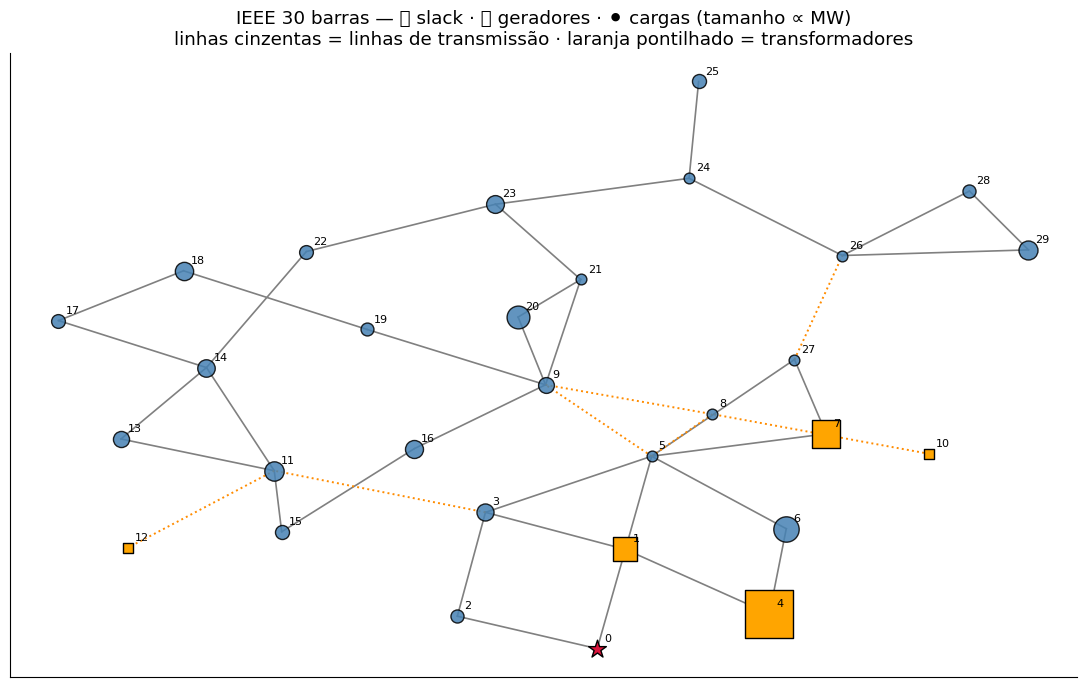

In [5]:
pos = coords_das_barras(net)                      # {bus: (x, y)}
carga_por_bus = net.load.groupby("bus").p_mw.sum()      # MW por barra
barras_gen = set(net.gen.bus.astype(int))
bus_slack = int(net.ext_grid.bus.iloc[0])

fig, ax = plt.subplots(figsize=(11, 7))

# --- arestas: linhas sólidas, trafos punteados ---
for _, ln in net.line.iterrows():
    (x1, y1), (x2, y2) = pos[int(ln.from_bus)], pos[int(ln.to_bus)]
    ax.plot([x1, x2], [y1, y2], color="gray", lw=1.2, zorder=1)
for _, tr in net.trafo.iterrows():
    (x1, y1), (x2, y2) = pos[int(tr.hv_bus)], pos[int(tr.lv_bus)]
    ax.plot([x1, x2], [y1, y2], color="darkorange", lw=1.4, ls=":", zorder=1)

# --- nós: tamanho ∝ carga, color segundo papel ---
for b, (x, y) in pos.items():
    mw = carga_por_bus.get(b, 0.0)
    size = 60 + 12 * mw                        # escala visual
    if b == bus_slack:
        ax.scatter(x, y, s=size + 120, marker="*", c="crimson", zorder=3, edgecolors="k")
    elif b in barras_gen:
        ax.scatter(x, y, s=size, marker="s", c="orange", zorder=3, edgecolors="k")
    else:
        ax.scatter(x, y, s=size, c="steelblue", zorder=3, edgecolors="k", alpha=0.85)
    ax.annotate(str(b), (x, y), textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_title("IEEE 30 barras — ⭐ slack · ⬛ geradores · ⚫ cargas (tamanho ∝ MW)\n"
             "linhas cinzentas = linhas de transmissão · laranja pontilhado = transformadores")
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); plt.show()

💡 **Interpretação.** Já se vê estrutura: há uma zona "troncal" de 132 kV (onde estão
quase todos os geradores) e uma zona de distribuição de 33 kV conectada pelos
transformadores naranjas. Essa fronteira física vai reaparecer uma e outra vez nos
análise matemáticos de hoje — guardem esta imagem mental.

✏️ **Para refletir:** se tivessem que apostar *agora* qual barra é a mais "importante" da
rede, qual elegirían e com que critério? Anotem: ao final do notebook o confrontamos
com três definições formais de importancia.

---
## 2 · Do sistema de potência ao grafo (§3.1.1)

### A decisão de modelagem

Um grafo é $G = (V, E)$: nós e arestas. Mas ao converter uma rede elétrica em grafo há
que tomar **decisões** que mudam as conclusões:

1. **Grafo topológico?** Só a conectividade: duas barras estão unidas ou não
   (Pagani & Aiello, 2013). Perde toda a física.
2. **Grafo ponderado por admitância?** O peso da aresta é $|y| = 1/|x_{pu}|$
   (Wang, Scaglione & Thomas, 2011): uma linha de baixa reatância "aproxima" eletricamente
   a seus extremos muito mais que uma de alta reatância.

Construiremos ambos e veremos onde diferem.

### 2.1 Passo prévio: todas os ramos em por-unidade

pandapower guarda linhas em **ohms** e transformadores em **% de tensão de curto-circuito**.
Para um grafo coerente precisamos uma unidade comum: a **reatância em p.u.** sobre a base
do sistema ($S_{base}$ = `net.sn_mva` = 100 MVA).

- **Linha:** $x_{pu} = \dfrac{x_{\Omega/km}\cdot \ell_{km}}{Z_{base}}$, com
  $Z_{base} = \dfrac{V_n^2}{S_{base}}$.
- **Transformador:** $x_{pu} = \dfrac{v_k\%}{100}\cdot\dfrac{S_{base}}{S_{n,trafo}}$,
  **corrigida pela posição do tap**: $x_{pu} \leftarrow x_{pu}\cdot \tau$, com
  $\tau = 1 + (tap_{pos}-tap_{neutral})\cdot\dfrac{step\%}{100}$.

> ⚠️ O detalhe do **tap** parece menor, mas sem ele nosso fluxo DC manual diferiria do
> de pandapower em ~0.3°. Com ele, coincidirá a **precisão de máquina** (vocês verão em §4).
> Moral da história: em redes, os "detalhes de engenharia" não são opcionais.

In [6]:
def ramos_da_rede(net):
    "Genera (bus_i, bus_j, x_pu, tipo) para cada linha e transformador."
    S_base = net.sn_mva                                  # 100 MVA em IEEE 30

    # ---- LÍNEAS: ohms -> p.u. -------------------------------------------
    for _, ln in net.line.iterrows():
        vn = net.bus.loc[int(ln.from_bus), "vn_kv"]      # tensão nominal [kV]
        z_base = vn ** 2 / S_base                        # impedancia base [ohm]
        x_pu = (ln.x_ohm_per_km * ln.length_km) / z_base
        yield int(ln.from_bus), int(ln.to_bus), float(x_pu), "linha"

    # ---- TRANSFORMADORES: vk% -> p.u., corrigiendo por tap ----------------
    for _, tr in net.trafo.iterrows():
        x_pu = (tr.vk_percent / 100.0) * (S_base / tr.sn_mva)
        if not np.isnan(tr.tap_pos):                     # tem tap definido?
            tau = 1 + (tr.tap_pos - tr.tap_neutral) * tr.tap_step_percent / 100.0
            x_pu *= tau                                  # reatância efectiva
        yield int(tr.hv_bus), int(tr.lv_bus), float(x_pu), "trafo"


# Olhemos as primeros ramos convertidas, para verificar que as magnitudes são razonables
ramos = pd.DataFrame(ramos_da_rede(net), columns=["de", "a", "x_pu", "tipo"])
print(f"{len(ramos)} ramos em total ({(ramos.tipo == 'linha').sum()} linhas, "
      f"{(ramos.tipo == 'trafo').sum()} trafos)")
ramos.head(8)

41 ramos em total (34 linhas, 7 trafos)


,de,a,x_pu,tipo
0,0,1,0.0575,linha
1,0,2,0.1652,linha
2,1,3,0.1737,linha
3,2,3,0.0379,linha
4,1,4,0.1983,linha
5,1,5,0.1763,linha
6,3,5,0.0414,linha
7,4,6,0.1160,linha


### 2.2 Os dois grafos

Com os ramos em p.u., os dois grafos são quatro linhas de código cada uno. Observem a
**única diferença**: o grafo de admitâncias adiciona `weight = 1/x_pu`.

In [7]:
def grafo_topologico(net) -> nx.Graph:
    "G = (V, E) sem pesos: só importa quem está conectado com quem."
    G = nx.Graph()
    G.add_nodes_from(sorted(net.bus.index))
    for i, j, _x, _tipo in ramos_da_rede(net):
        G.add_edge(i, j)
    return G


def grafo_admitancia(net) -> nx.Graph:
    "Igual, mas cada aresta pesa |e| = 1/x_pu: a 'proximidade elétrica'."
    G = nx.Graph()
    G.add_nodes_from(sorted(net.bus.index))
    for i, j, x_pu, _tipo in ramos_da_rede(net):
        if abs(x_pu) < 1e-12:        # proteção contra reatância nula
            continue
        G.add_edge(i, j, weight=1.0 / abs(x_pu))
    return G


G_top = grafo_topologico(net)
G_adm = grafo_admitancia(net)
print(f"G topológico : {G_top.number_of_nodes()} nós, {G_top.number_of_edges()} arestas")
print(f"G admitância : {G_adm.number_of_nodes()} nós, {G_adm.number_of_edges()} arestas")
print(f"Conexo? {nx.is_connected(G_top)}  (se não o fora, habría apagón por desenho!)")

G topológico : 30 nós, 41 arestas
G admitância : 30 nós, 41 arestas
Conexo? True  (se não o fora, habría apagón por desenho!)


> 🔎 **Nota:** entre duas barras pode haver mais de um ramo (linhas paralelas). `nx.Graph`
> colapsa os paralelos em uma sozinha aresta — por isso o grafo pode ter menos arestas que
> ramos tem a rede (41 ramos → 41 ou menos arestas). Para as análises topológicos de hoje
> isso é aceitável; para o fluxo DC de §4 trabalharemos com a lista completa de ramos.

### 2.3 A matriz de adjacência e os graus

A **matriz de adjacência** $A$ ($A_{ij}=1$ se $i\sim j$) é a primeira "foto" algébrica
do grafo. Sua soma por linhas é o **grau** $k_i$ de cada nó.

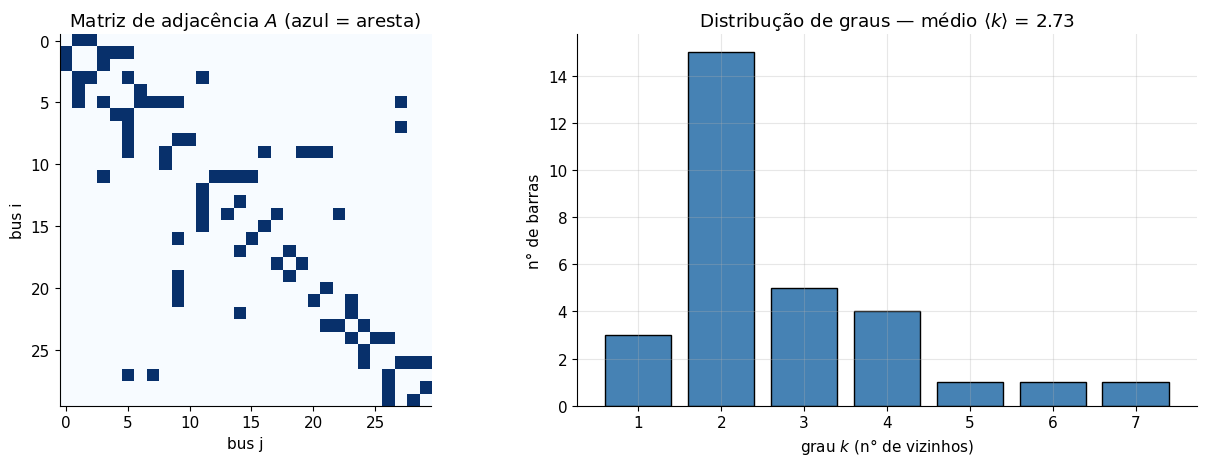

Barras de maior grau: {5: np.int64(7), 9: np.int64(6), 11: np.int64(5), 1: np.int64(4)}


In [8]:
nodos = sorted(G_top.nodes())
A = nx.to_numpy_array(G_top, nodelist=nodos, weight=None)   # binaria, 30x30
grados = A.sum(axis=1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# --- (a) a matriz A como imagem ---
axes[0].imshow(A, cmap="Blues")
axes[0].set_title("Matriz de adjacência $A$ (azul = aresta)")
axes[0].set_xlabel("bus j"); axes[0].set_ylabel("bus i"); axes[0].grid(False)

# --- (b) histogramo de graus ---
axes[1].bar(*np.unique(grados, return_counts=True), color="steelblue", edgecolor="k")
axes[1].set_xlabel("grau $k$ (n° de vizinhos)"); axes[1].set_ylabel("n° de barras")
axes[1].set_title(f"Distribução de graus — médio $\\langle k\\rangle$ = {grados.mean():.2f}")

plt.tight_layout(); plt.show()

print("Barras de maior grau:",
      dict(sorted(zip(nodos, grados), key=lambda t: -t[1])[:4]))

💡 **Interpretação.** Dois fatos típicos de **toda** rede de transmissão real:

1. **A rede é esparsa (sparse):** $\langle k \rangle \approx 2.7$ — cada barra se conecta em
   médio com menos de 3 vizinhas. Compare com uma rede social, onde $\langle k\rangle$
   pode ser de centenas. A razão é econômica: cada aresta é uma linha de alta tensão
   que custa milhões de dólares por km.
2. **Não há "hubs" gigantes:** o grau máximo é ~7. As redes elétricas **não** são redes
   *scale-free* como Internet — a física e o custo limitam quantas linhas chegam a uma
   subestação. Isto importa para a robustez, como veremos em §6.

---
## 3 · Análise espectral: o que os autovalores sabem da rede

### O Laplaciano do grafo

A matriz central de toda a sessão é o **Laplaciano**:

$$L = D - A,$$

onde $D = \mathrm{diag}(k_1,\dots,k_n)$ é a matriz de graus. Três propriedades que vamos
*verificar numericamente* (não acreditem em nada que não possam comprovar):

1. $L$ é simétrica e semidefinida positiva → todos seus autovalores são reais e $\geq 0$.
2. $\lambda_1 = 0$ sempre, com autovetor constante $\mathbb{1}$ (as linhas de $L$ somam zero).
3. **O número de autovalores nulos = número de componentes conexas.** Se a rede está
   inteira, há exatamente um zero.

O segundo autovalor, $\lambda_2$, é a **conectividade algébrica** (Fiedler, 1973):
mede quão "difícil" é partir a rede em dois. E seu autovetor associado — o
**vetor de Fiedler** — nos diz *por onde* cortá-la.

In [9]:
# --- Construção explícita de L = D - A ------------------------------------
D = np.diag(grados)             # matriz de graus na diagonal
L = D - A                       # isso é todo!

# --- Verificação das 3 propriedades ---------------------------------------
print("1) Simétrica?", np.allclose(L, L.T))
print("2) Filas somam 0?", np.allclose(L.sum(axis=1), 0))

# eigh = autovalores de matrizes simétricas (devuelve todo ordenado e real)
lambdas, V = np.linalg.eigh(L)
print("3) Menores autovalores:", np.round(lambdas[:4], 4))
print(f"   -> exatamente um autovalor ~0 => 1 componente conexa ✓")
print(f"   Conectividad algébrica  λ2 = {lambdas[1]:.4f}")

1) Simétrica? True
2) Filas somam 0? True
3) Menores autovalores: [0.     0.2121 0.2982 0.4396]
   -> exatamente um autovalor ~0 => 1 componente conexa ✓
   Conectividad algébrica  λ2 = 0.2121


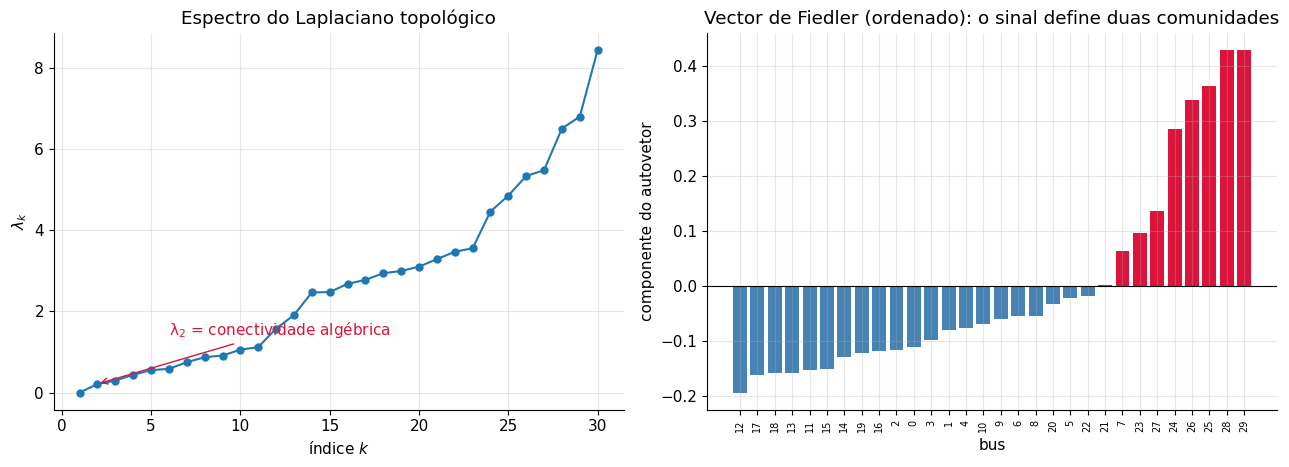

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# --- (a) o espectro completo ---
axes[0].plot(range(1, len(lambdas) + 1), lambdas, "o-", ms=5)
axes[0].annotate("λ$_2$ = conectividade algébrica", xy=(2, lambdas[1]),
                 xytext=(6, lambdas[1] + 1.2),
                 arrowprops=dict(arrowstyle="->", color="crimson"), color="crimson")
axes[0].set_xlabel("índice $k$"); axes[0].set_ylabel("$\\lambda_k$")
axes[0].set_title("Espectro do Laplaciano topológico")

# --- (b) o vetor de Fiedler ordenado ---
fiedler = V[:, 1]                                   # autovetor de λ2
orden = np.argsort(fiedler)
colores = ["crimson" if fiedler[i] >= 0 else "steelblue" for i in orden]
axes[1].bar(range(len(fiedler)), fiedler[orden], color=colores)
axes[1].set_xticks(range(len(fiedler)))
axes[1].set_xticklabels([nodos[i] for i in orden], fontsize=7, rotation=90)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("Vector de Fiedler (ordenado): o sinal define duas comunidades")
axes[1].set_xlabel("bus"); axes[1].set_ylabel("componente do autovetor")
plt.tight_layout(); plt.show()

### 3.1 A bipartição espectral, vista no mapa

A receita da **partição espectral** é: *pinta cada nó segundo o sinal de seu
componente no vetor de Fiedler*. Essa é (aproximadamente) a forma de cortar a rede
rompendo o mínimo de arestas. Vejamos se o álgebra "descobre" sozinha a estrutura física
que vimos em §1.2.

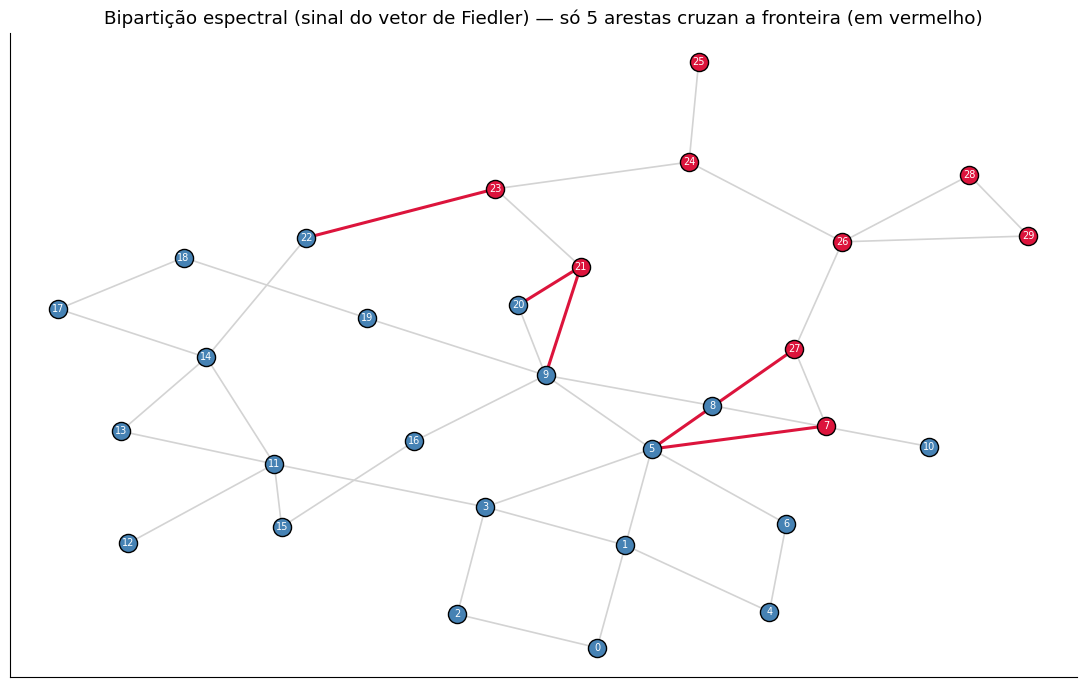

In [11]:
fig, ax = plt.subplots(figsize=(11, 7))

# arestas, marcando em vermelho as que cruzan a fronteira entre comunidades
signo = {b: (fiedler[k] >= 0) for k, b in enumerate(nodos)}
cortadas = 0
for u, v in G_top.edges():
    (x1, y1), (x2, y2) = pos[u], pos[v]
    if signo[u] != signo[v]:
        ax.plot([x1, x2], [y1, y2], color="crimson", lw=2.2, zorder=2)
        cortadas += 1
    else:
        ax.plot([x1, x2], [y1, y2], color="lightgray", lw=1.2, zorder=1)

for b, (x, y) in pos.items():
    ax.scatter(x, y, s=170, c="crimson" if signo[b] else "steelblue",
               edgecolors="k", zorder=3)
    ax.annotate(str(b), (x, y), ha="center", va="center", fontsize=7, color="w", zorder=4)

ax.set_title(f"Bipartição espectral (sinal do vetor de Fiedler) — "
             f"só {cortadas} arestas cruzan a fronteira (em vermelho)")
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); plt.show()

💡 **Interpretação.** O álgebra linear, sem saber nada de kV nem de geografia, separou a
rede em dois blocos coesos unidos por um punhado de linhas. Em sistemas reais essas poucas
arestas "fronteira" são os **corredores de transmissão críticos**: quando se congestionam,
os preços das duas zonas se separam (isso é exatamente o que estudaremos na
Sessão 2 com os preços nodais!).

✏️ **Para refletir:** $\lambda_2$ desta rede é pequeno (~0.2). O que aconteceria a $\lambda_2$
se duplicássemos todas as linhas? E se removêssemos uma das arestas vermelhas? Hipóteses agora,
verificação no laboratório.

---
## 4 · O fluxo de potência DC *é* uma equação de grafo

### A física em três linhas

Para redes de alta tensão, a aproximação DC (Dörfler, Simpson-Porco & Bullo, 2018) diz
que o fluxo ativo pelo ramo $\ell=(i,j)$ é

$$p_{ij} = b_{ij}\,(\theta_i - \theta_j), \qquad b_{ij} = \tfrac{1}{x_{ij}},$$

e o balanço de potência em cada barra ($P_i$ = generação − carga) se escreve

$$P_i = \sum_{j \sim i} b_{ij}(\theta_i - \theta_j)
\quad\Longleftrightarrow\quad
\boxed{P = B\,\theta},$$

onde $B$ é o **Laplaciano ponderado por suscetâncias** — a mesma construção
$D - A$ de §3, mas com $b_{ij}$ no lugar de uns. *Fluxo de potência = difusão em um grafo.*

> Convenção de sinais: aqui definimos $B$ como Laplaciano (diagonal positiva), de modo que
> $P = B\theta$. Alguns textos escrevem $P=-B\theta$ com a convenção de sinais oposta
> para $B$; é só notação.

### 4.1 Construir $B$ à mão

In [12]:
def laplaciano_suscetancias(net) -> np.ndarray:
    "B tal que P = B·θ (aproximação DC, sem perdas)."
    bidx = {b: i for i, b in enumerate(sorted(net.bus.index))}   # bus -> linha
    n = len(bidx)
    B = np.zeros((n, n))
    for i, j, x_pu, _tipo in ramos_da_rede(net):
        if abs(x_pu) < 1e-12:
            continue
        b = 1.0 / x_pu                      # suscetância da rama
        ii, jj = bidx[i], bidx[j]
        B[ii, jj] -= b                      # fora da diagonal: -b
        B[jj, ii] -= b
        B[ii, ii] += b                      # diagonal: soma das b incidentes
        B[jj, jj] += b
    return B


bidx = {b: i for i, b in enumerate(sorted(net.bus.index))}
B = laplaciano_suscetancias(net)
print("B simétrica?", np.allclose(B, B.T), "| linhas somam 0?", np.allclose(B.sum(1), 0, atol=1e-9))
print("=> B é um Laplaciano legítimo: mesma álgebra de §3, pesos físicos.")

B simétrica? True | linhas somam 0? True
=> B é um Laplaciano legítimo: mesma álgebra de §3, pesos físicos.


### 4.2 O vetor de injeções e o problema do slack

$B$ é singular (uma linha redundante: o que entra deve sair). Por isso fixa-se uma barra de
**referência (slack)**: seu ângulo é imposto em $\theta_{slack}=0$ e sua injeção absorve o
desbalanço do sistema. Eliminamos sua linha e coluna e resolvemos o sistema **reduzido**.

In [13]:
def injecoes_pu(net) -> np.ndarray:
    "P_i = generação - carga, em p.u. (o slack se completa depois)."
    P = np.zeros(len(bidx))
    S_base = net.sn_mva
    for _, ld in net.load.iterrows():
        P[bidx[int(ld.bus)]] -= ld.p_mw / S_base      # cargas: extraen potência
    for _, g in net.gen.iterrows():
        P[bidx[int(g.bus)]] += g.p_mw / S_base        # geradores: injetam
    return P


def resolver_angulos_dc(net):
    "Resuelve B·θ = P com o truco do slack. Devuelve (θ em graus, idx slack)."
    n = len(bidx)
    P = injecoes_pu(net)
    slack = bidx[int(net.ext_grid.bus.iloc[0])]
    resto = [k for k in range(n) if k != slack]
    P[slack] = -P[resto].sum()              # o slack equilibra o sistema
    theta = np.zeros(n)                     # θ_slack = 0 por definição
    theta[resto] = np.linalg.solve(B[np.ix_(resto, resto)], P[resto])
    return np.degrees(theta), slack


theta_manual, slack = resolver_angulos_dc(net)
print(f"Ángulos resueltos. θ do slack (bus {nodos[slack]}) = {theta_manual[slack]:.1f}° ✓")

Ángulos resueltos. θ do slack (bus 0) = 0.0° ✓


### 4.3 O momento da verdade: validação contra pandapower

Nosso modelo de 25 linhas de NumPy reproduz o software profissional? Comparamos
nossos $\theta$ com `net.res_bus.va_degree` (o resultado do `rundcpp` de §1).
**Nunca confiem em um modelo próprio sem validá-lo contra uma referência.**

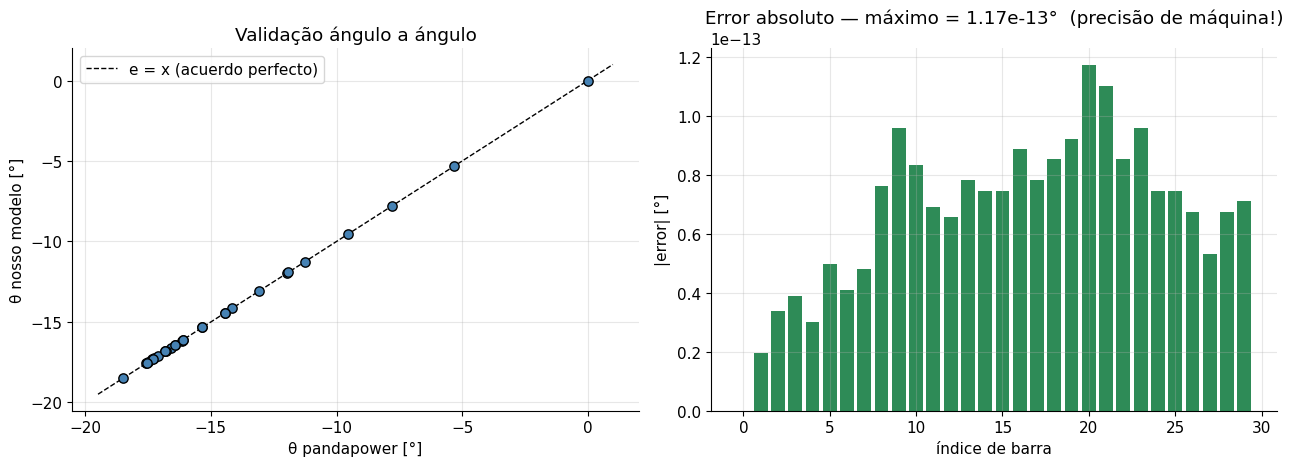

In [14]:
theta_pp = net.res_bus.va_degree.values            # referência pandapower

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].scatter(theta_pp, theta_manual, s=45, c="steelblue", edgecolors="k", zorder=3)
lim = [theta_pp.min() - 1, theta_pp.max() + 1]
axes[0].plot(lim, lim, "k--", lw=1, label="e = x (acuerdo perfecto)")
axes[0].set_xlabel("θ pandapower [°]"); axes[0].set_ylabel("θ nosso modelo [°]")
axes[0].legend(); axes[0].set_title("Validação ángulo a ángulo")

err = np.abs(theta_manual - theta_pp)
axes[1].bar(range(len(err)), err, color="seagreen")
axes[1].set_xlabel("índice de barra"); axes[1].set_ylabel("|error| [°]")
axes[1].set_title(f"Error absoluto — máximo = {err.max():.2e}°  (precisão de máquina!)")
plt.tight_layout(); plt.show()

💡 **Interpretação.** Erro máximo ~$10^{-13}$ graus: nosso Laplaciano **é exatamente**
o modelo DC de pandapower. Sem a correção de tap de §2.1 o erro seria ~0.3° —
testem comentá-la e rodar de novo esta célula para vê-lo.

### 4.4 De ângulos a fluxos: quais linhas trabalham mais?

Com os $\theta$ resolvidos, o fluxo de cada ramo é $p_\ell = b_\ell(\theta_i - \theta_j)$.

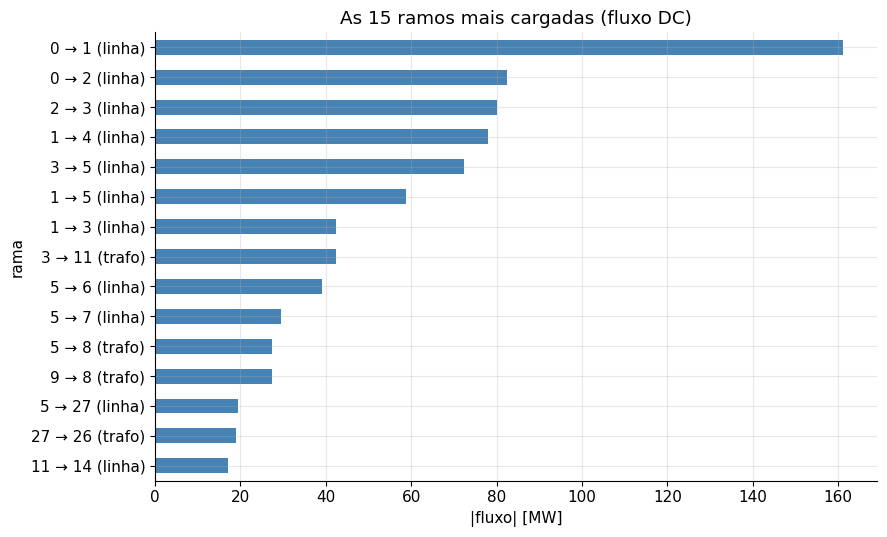

,de,a,tipo,p_mw,abs_mw
0,0,1,linha,161.026347,161.026347
1,0,2,linha,82.373653,82.373653
2,2,3,linha,79.973653,79.973653
3,1,4,linha,77.970404,77.970404
4,3,5,linha,72.424085,72.424085


In [15]:
filas = []
for i, j, x_pu, tipo in ramos_da_rede(net):
    th_i, th_j = np.radians(theta_manual[bidx[i]]), np.radians(theta_manual[bidx[j]])
    p_pu = (th_i - th_j) / x_pu                       # fluxo DC em p.u.
    filas.append({"de": i, "a": j, "tipo": tipo, "p_mw": p_pu * net.sn_mva})
flujos = pd.DataFrame(filas)
flujos["abs_mw"] = flujos.p_mw.abs()
flujos = flujos.sort_values("abs_mw", ascending=False).reset_index(drop=True)

ax = flujos.head(15).plot.barh(x="de", y="abs_mw", color="steelblue", legend=False,
                               figsize=(9, 5.5))
ax.set_yticklabels([f"{r.de} → {r.a} ({r.tipo})" for r in flujos.head(15).itertuples()])
ax.invert_yaxis()
ax.set_xlabel("|fluxo| [MW]"); ax.set_ylabel("rama")
ax.set_title("As 15 ramos mais cargadas (fluxo DC)")
plt.tight_layout(); plt.show()
flujos.head(5)

💡 **Interpretação.** Os ramos mais carregados saem da zona de geração. Quando na
Sessão 2 impusermos **limites térmicos** a estas linhas, os que estão no topo desta lista
serão os candidatos a **congestionar** — e o congestionamento é o que separa os preços
nodais. Este ranking é, literalmente, o "trailer" da próxima sessão.

---
## 5 · PTDF: a "função de influência" de cada barra (§3.1.5)

### A pergunta que responde

> *Se injeto 1 MW extra na barra $k$ (e o retiro no slack), quanto muda o fluxo
> de **cada** linha?*

A resposta é a matriz **PTDF** (Power Transfer Distribution Factors), de tamanho
$L \times n$ (ramos × barras):

$$\Delta p_\ell = \mathrm{PTDF}_{\ell k}\cdot \Delta P_k.$$

Obtém-se encadeando duas coisas que já temos: a inversa do Laplaciano reduzido
($\theta = B_{red}^{-1} P$) e a equação de fluxo de ramo ($p_\ell = b_\ell(\theta_i-\theta_j)$).

### 5.1 Primeiro, à mão, em uma rede de brinquedo

Antes da matriz 41×30 do IEEE 30, construamos a intuição com **3 barras**:

```
        bus 0 (slack)
        /          \
   x = 0.1       x = 0.2
      /              \
   bus 1 —— x = 0.2 —— bus 2
```

Se injeto 1 p.u. no **bus 1** e o retiro no bus 0, a potência tem dois caminhos:
o direto (reatância 0.1) e o longo via barra 2 (reatância 0.2+0.2 = 0.4). Em DC o fluxo
se reparte **inversamente proporcional à reatância do caminho**:

$$p_{1\to0}^{directo} = \frac{0.4}{0.1+0.4} = 0.8, \qquad
p_{1\to2\to0} = \frac{0.1}{0.5} = 0.2.$$

Verifiquemos com a maquinaria geral.

In [16]:
def ptdf_desde_B(B, ramos_idx, susceptancias, slack):
    "PTDF[l, k] = d(fluxo da ramo l) / d(injeção na barra k)."
    n = B.shape[0]
    resto = [k for k in range(n) if k != slack]
    B_red_inv = np.linalg.inv(B[np.ix_(resto, resto)])      # θ = B⁻¹·P (reducido)

    L = len(ramos_idx)
    PTDF = np.zeros((L, n))
    pos_de = {k: c for c, k in enumerate(resto)}            # coluna de cada barra
    for l, (i, j) in enumerate(ramos_idx):
        # linha l de H: p_l = b_l·(θ_i - θ_j)  =>  derivada vía B_red_inv
        fila_H = np.zeros(len(resto))
        if i != slack:
            fila_H[pos_de[i]] += susceptancias[l]
        if j != slack:
            fila_H[pos_de[j]] -= susceptancias[l]
        PTDF[l, resto] = fila_H @ B_red_inv
    return PTDF


# ---- Rede de brinquedo de 3 barras --------------------------------------------
x_toy = {(0, 1): 0.1, (0, 2): 0.2, (1, 2): 0.2}
B_toy = np.zeros((3, 3))
for (i, j), x in x_toy.items():
    b = 1 / x
    B_toy[i, j] -= b; B_toy[j, i] -= b; B_toy[i, i] += b; B_toy[j, j] += b

ramos_toy = list(x_toy.keys())
b_toy = np.array([1 / x for x in x_toy.values()])
PTDF_toy = ptdf_desde_B(B_toy, ramos_toy, b_toy, slack=0)

tabla = pd.DataFrame(PTDF_toy, columns=["iny. bus 0", "iny. bus 1", "iny. bus 2"],
                     index=[f"ramo {i}-{j}" for i, j in ramos_toy]).round(3)
print("PTDF da rede de brinquedo (slack = bus 0):")
display(tabla)
print("Columna 'iny. bus 1': a ramo 0-1 ve -0.8 (recibe o 80% do MW, para o bus 0)")
print("e os ramos 0-2 / 1-2 ven ±0.2 (o 20% restante via o caminho longo). ✓ como à mão")

PTDF da rede de brinquedo (slack = bus 0):


,iny. bus 0,iny. bus 1,iny. bus 2
ramo 0-1,0.0,-0.8,-0.4
ramo 0-2,0.0,-0.2,-0.6
ramo 1-2,0.0,0.2,-0.4


Columna 'iny. bus 1': a ramo 0-1 ve -0.8 (recibe o 80% do MW, para o bus 0)
e os ramos 0-2 / 1-2 ven ±0.2 (o 20% restante via o caminho longo). ✓ como à mão


✔️ A maquinaria reproduz o cálculo manual. Duas propriedades para fixar:

- **A coluna do slack é zero** (injetar e retirar na mesma barra não move nada).
- Cada MW se reparte por **todos** os caminhos ao mesmo tempo — em uma rede elétrica não dá para
  "rotear" o fluxo como um pacote de internet. Esta é a grande diferença entre redes
  elétricas e redes de transporte/dados, e a causa dos *loop flows*.

### 5.2 Agora sim: a PTDF do IEEE 30, como mapa de calor

PTDF: (41, 30) (ramos × barras)


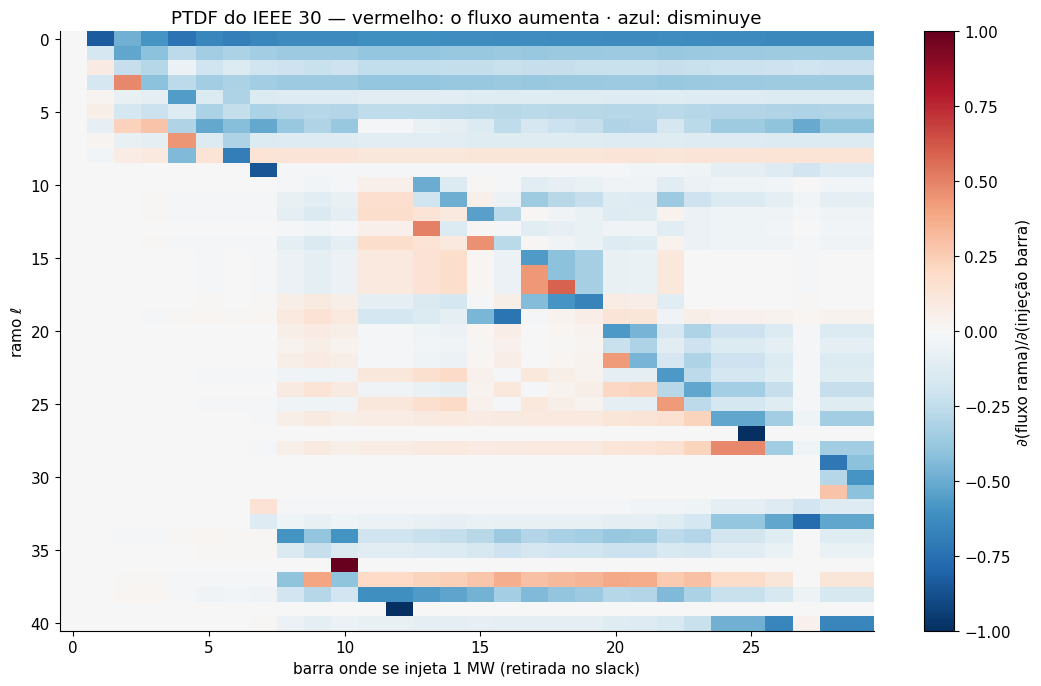

In [17]:
# ---- suscetâncias e ramos do IEEE 30 em indexado 0..n-1 -------------------
ramos_idx, suscept = [], []
for i, j, x_pu, _tipo in ramos_da_rede(net):
    if abs(x_pu) < 1e-12:
        continue
    ramos_idx.append((bidx[i], bidx[j]))
    suscept.append(1.0 / x_pu)
suscept = np.array(suscept)

PTDF = ptdf_desde_B(B, ramos_idx, suscept, slack)
print("PTDF:", PTDF.shape, "(ramos × barras)")

fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(PTDF, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xlabel("barra onde se injeta 1 MW (retirada no slack)")
ax.set_ylabel("ramo $\\ell$")
ax.set_title("PTDF do IEEE 30 — vermelho: o fluxo aumenta · azul: disminuye")
plt.colorbar(im, label="∂(fluxo rama)/∂(injeção barra)")
ax.grid(False); plt.tight_layout(); plt.show()

💡 **Como ler o mapa.** Cada **coluna** é a "impressão digital" de uma barra: quais linhas
perturba ao injetar. Colunas quase brancas = barras eletricamente próximas ao slack.
Linhas com muitas cores intensas = linhas sensíveis a injeções em muitas partes —
candidatas a serem gargalos sistêmicos.

### 5.3 Betweenness elétrica vs. betweenness topológica

Com a PTDF definimos a **betweenness elétrica** de uma barra (Wang et al., 2011,
simplificada): a soma $\sum_\ell |\mathrm{PTDF}_{\ell k}|$ — *quanto fluxo total move a
barra $k$ pela rede*. A pergunta interessante: **coincide com a betweenness topológica**
(a de "caminhos mais curtos") **que usaria um analista de redes sociais?**

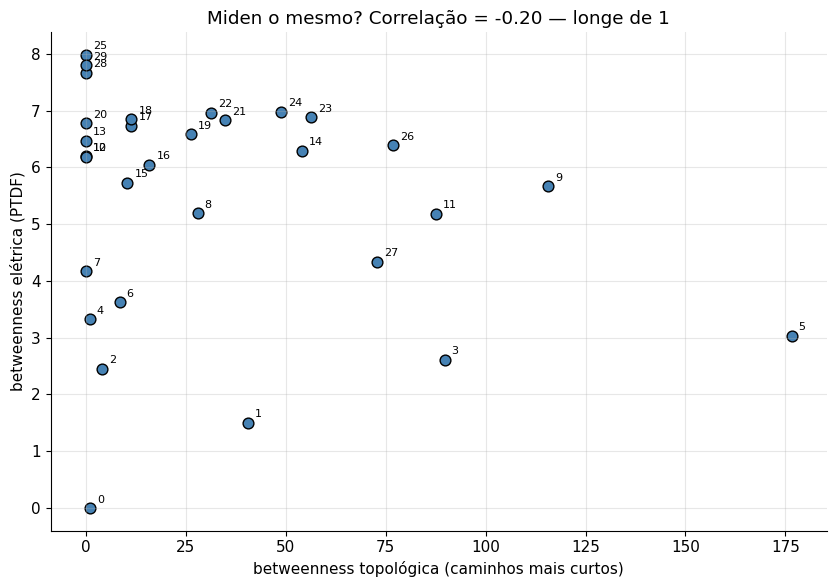

Top-5 segundo cada métrica:


,topológica,elétrica
5,176.583333,NaN
9,115.666667,NaN
3,89.750000,NaN
11,87.500000,NaN
26,76.833333,NaN
25,NaN,7.978593
29,NaN,7.795826
28,NaN,7.668455
24,NaN,6.978593
22,NaN,6.957577


In [18]:
# --- elétrica: norma-1 de cada coluna da PTDF (com limiar anti-ruído) ---
Pabs = np.abs(PTDF.copy())
Pabs[Pabs < 1e-3] = 0.0
btw_elec = pd.Series(Pabs.sum(axis=0), index=nodos, name="elétrica")

# --- topológica: caminhos mais curtos sobre o grafo sem pesos -----------------
btw_topo = pd.Series(nx.betweenness_centrality(G_top, normalized=False),
                     name="topológica").sort_index()

comp = pd.concat([btw_topo, btw_elec], axis=1)

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(comp["topológica"], comp["elétrica"], s=60, c="steelblue", edgecolors="k")
for b, fila in comp.iterrows():
    ax.annotate(str(b), (fila["topológica"], fila["elétrica"]),
                textcoords="offset points", xytext=(5, 4), fontsize=8)
r = np.corrcoef(comp["topológica"], comp["elétrica"])[0, 1]
ax.set_xlabel("betweenness topológica (caminhos mais curtos)")
ax.set_ylabel("betweenness elétrica (PTDF)")
ax.set_title(f"Miden o mesmo? Correlação = {r:.2f} — longe de 1")
plt.tight_layout(); plt.show()

print("Top-5 segundo cada métrica:")
display(pd.concat([comp["topológica"].nlargest(5), comp["elétrica"].nlargest(5)], axis=1))

💡 **Interpretação (resultado contraintuitivo n°1).** As duas métricas estão
correlacionadas, mas **o ranking muda**: há barras topologicamente "comuns" que
são eletricamente centrais, e vice-versa. A razão: a eletricidade **não viaja pelo
caminho mais curto** — se reparte por todos os caminhos segundo as reatâncias (vimos isso na
rede de brinquedo). Moral da história metodológica para as teses de vocês: *importar métricas de outras
disciplinas sem adaptar a física subjacente pode ordenar mal as prioridades de investimento
ou de proteção.*

---
## 6 · Falhas em cascata: o modelo de Motter & Lai (§3.1.2)

### As três regras do modelo

Motter & Lai (2002) propuseram o modelo mínimo de cascata por sobrecarga:

1. **Carga inicial:** cada nó $i$ transporta $L_i(0)$ = seu betweenness na rede intacta
   (proxy de "quanto tráfego passa por aqui").
2. **Capacidade fixa:** $C_i = \alpha \cdot L_i(0)$, com $\alpha \geq 1$ o **fator de
   tolerância** — o sobredimensionamento que o planejador pagou ao construir.
3. **Dinâmica:** removem-se os nós atacados → os fluxos se **redistribuem**
   (recalcula-se a betweenness na rede sobrevivente) → todo nó com $L_i > C_i$
   desliga → repetir até que nenhum outro se sobrecarregue.

É uma caricatura do mecanismo real dos grandes apagões (Itália 2003, Índia 2012):
não é a falha inicial que apaga o país, é a **redistribuição**.

In [19]:
def cascada_motter_lai(G_full, nodos_atacados, alpha=1.5, max_iter=100, traza=False):
    "Simula a cascata e devuelve um dict com o resultado (e a traza opcional)."
    todos = list(G_full.nodes())

    # Regla 1: carga inicial = betweenness na rede intacta
    L0 = pd.Series(nx.betweenness_centrality(G_full, normalized=False))
    # Regra 2: capacidade proporcional, fixada de uma vez e para sempre
    C = alpha * L0

    atacados = set(nodos_atacados) & set(todos)
    vivos = set(todos) - atacados
    historia = [len(vivos)]
    en_cascada = 0

    for _ in range(max_iter):                       # Regla 3: iterar
        H = G_full.subgraph(vivos)                  # a rede superviviente
        if H.number_of_edges() == 0:
            break
        L = nx.betweenness_centrality(H, normalized=False)   # redistribução
        sobrecargados = [v for v in vivos if L.get(v, 0.0) > C[v] + 1e-12]
        if not sobrecargados:                       # ninguém mais se dispara: fin
            break
        vivos -= set(sobrecargados)
        en_cascada += len(sobrecargados)
        historia.append(len(vivos))

    res = {"removidos_inicial": len(atacados), "en_cascada": en_cascada,
           "vivos_final": len(vivos), "frac_viva": len(vivos) / len(todos)}
    return (res, historia) if traza else res

### 6.1 Demo: ataque direcionado vs. falha aleatória

Testamos dois cenários com a **mesma** tolerância $\alpha = 1.2$:

- remover **a barra de maior betweenness** (ataque informado);
- remover **uma barra qualquer** (falha aleatória).

Ataque ao bus 5 (máx. betweenness): {'removidos_inicial': 1, 'en_cascada': 15, 'vivos_final': 14, 'frac_viva': 0.4666666666666667}
Fallo do bus 25 (aleatorio)     : {'removidos_inicial': 1, 'en_cascada': 0, 'vivos_final': 29, 'frac_viva': 0.9666666666666667}


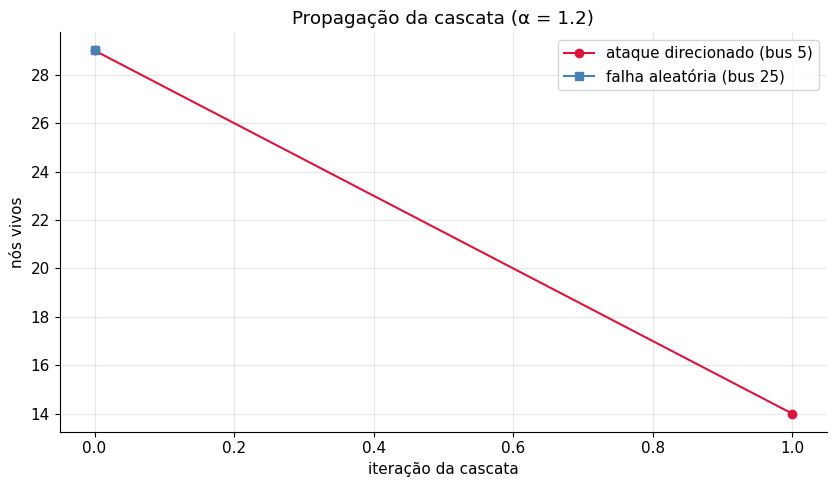

In [20]:
alpha_demo = 1.2
bus_central = btw_topo.idxmax()                 # o nó mais "intermediario"
bus_aleatorio = int(rng.choice([b for b in nodos if b != bus_central]))

res_atq, hist_atq = cascada_motter_lai(G_top, [bus_central], alpha_demo, traza=True)
res_rnd, hist_rnd = cascada_motter_lai(G_top, [bus_aleatorio], alpha_demo, traza=True)

print(f"Ataque ao bus {bus_central} (máx. betweenness): {res_atq}")
print(f"Fallo do bus {bus_aleatorio} (aleatorio)     : {res_rnd}")

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(hist_atq, "o-", color="crimson", label=f"ataque direcionado (bus {bus_central})")
ax.plot(hist_rnd, "s-", color="steelblue", label=f"falha aleatória (bus {bus_aleatorio})")
ax.set_xlabel("iteração da cascata"); ax.set_ylabel("nós vivos")
ax.set_title(f"Propagação da cascata (α = {alpha_demo})")
ax.legend(); plt.tight_layout(); plt.show()

💡 **Interpretação.** Mesmo modelo, mesma rede, mesma tolerância — mas o resultado depende
brutalmente de **qual** nó falha. As redes esparsas e heterogêneas são **robustas ao
acaso e frágeis ao ataque**: a lição central de Motter & Lai.

### 6.2 Análise N−1: o "mapa de risco" da rede

Em planejamento se chama **critério N−1** exigir que a rede sobreviva à perda de
*qualquer* elemento individual. Percorramos as 30 barras, uma de cada vez, e meçamos a
extensão da cascata que cada uma provoca.

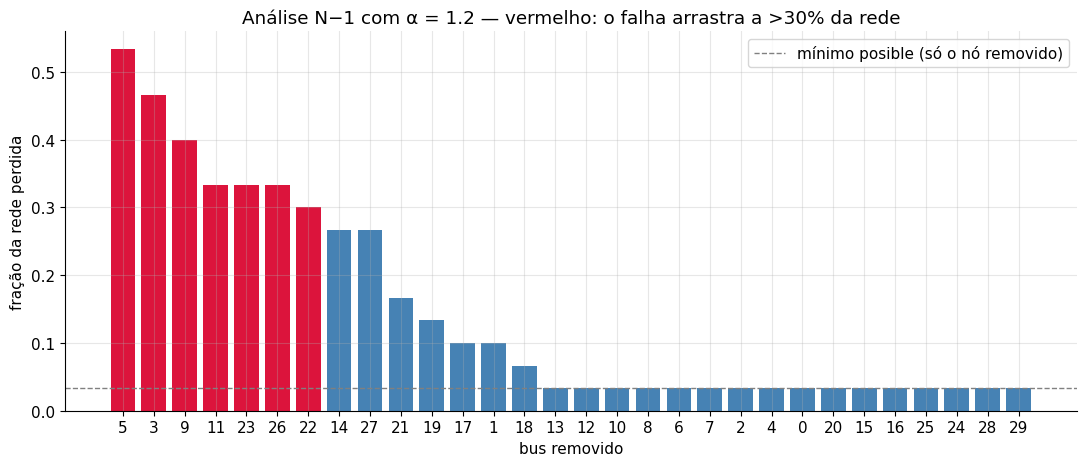

In [21]:
def extension_cascada_n1(G_full, alpha=1.5):
    "Para cada nó: 1 - fração viva tras removerlo (0 = nada pasó, 1 = colapso)."
    return pd.Series({v: 1.0 - cascada_motter_lai(G_full, [v], alpha)["frac_viva"]
                      for v in G_full.nodes()}, name="extension")

ext = extension_cascada_n1(G_top, alpha=1.2).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 4.8))
colores = ["crimson" if v > 0.3 else "steelblue" for v in ext.values]
ax.bar(ext.index.astype(str), ext.values, color=colores)
ax.axhline(1/30, color="gray", ls="--", lw=1,
           label="mínimo posible (só o nó removido)")
ax.set_xlabel("bus removido"); ax.set_ylabel("fração da rede perdida")
ax.set_title("Análise N−1 com α = 1.2 — vermelho: o falha arrastra a >30% da rede")
ax.legend(); plt.tight_layout(); plt.show()

### 6.3 Quanta tolerância comprar? A curva robustez–custo

$\alpha$ é uma decisão **econômica**: capacidade de sobra custa dinheiro. Varramos
$\alpha \in [1.0,\, 2.0]$ atacando sempre o nó mais central, e vejamos quanta robustez
compra cada ponto de tolerância.

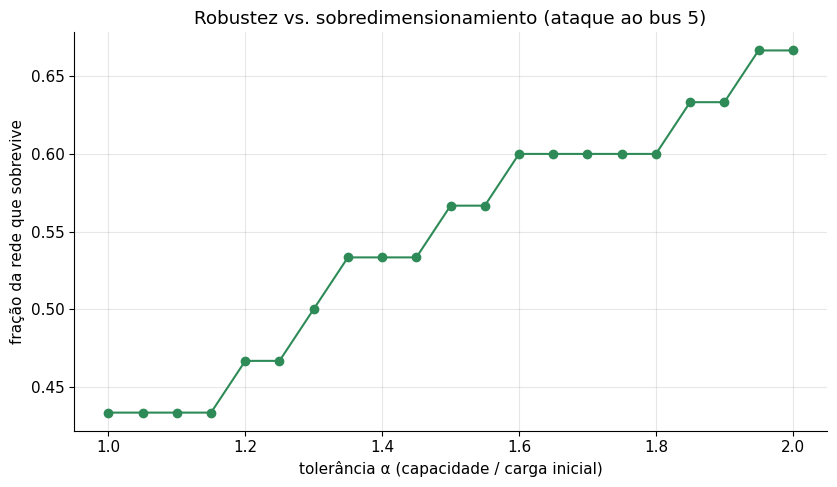

In [22]:
alphas = np.linspace(1.0, 2.0, 21)
frac_viva = [cascada_motter_lai(G_top, [bus_central], a)["frac_viva"] for a in alphas]

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(alphas, frac_viva, "o-", color="seagreen")
ax.set_xlabel("tolerância α (capacidade / carga inicial)")
ax.set_ylabel("fração da rede que sobrevive")
ax.set_title(f"Robustez vs. sobredimensionamiento (ataque ao bus {bus_central})")
plt.tight_layout(); plt.show()

💡 **Interpretação (resultado contraintuitivo n°2).** A curva **não é suave**: há saltos.
Passar de $\alpha=1.05$ a $1.10$ pode não comprar nada, e de $1.25$ a $1.30$ salvar metade da
rede. A robustez ante cascatas é um fenômeno **de limiar**, não incremental — péssima
notícia para quem planeja com análise marginal, e um argumento a favor de simular
explicitamente as cascatas em vez de extrapolar.

✏️ **Para refletir:** este modelo usa betweenness topológica como proxy de carga. O que
mudaria se usássemos os **fluxos DC reais** de §4 como carga e os limites térmicos como
capacidade? (Spoiler: é um dos exercícios do laboratório.)

---
## 7 · Quem é vizinho de quem? As quatro matrizes $W$ (§3.1.4)

### A ponte para a econometria espacial

Na Sessão 2 (Parte V) estimaremos modelos do tipo

$$y = \rho\, W y + X\beta + \varepsilon \qquad \text{(modelo SAR)},$$

onde $W$ — a **matriz de pesos espaciais** — codifica *quem influencia quem*.
Em econometria regional clássica, $W$ sai da geografia (municípios contíguos). Mas em
uma rede elétrica, o que é "ser vizinho"? Há (pelo menos) **quatro respostas defensáveis**,
e a escolha **muda os resultados** de qualquer modelo posterior. Construamos as quatro.

| # | Construção | Noção de vizinhança |
|---|---|---|
| 1 | $W = A$ (adjacência binaria) | "compartilham uma linha física" |
| 2 | $W_{ij} = 1/Z_{ef}(i,j)$ | proximidade **elétrica** (distância de resistência efetiva, Klein & Randić 1993) |
| 3 | PTDF com limiar | "uma transação entre $i$ e $j$ sacode muito alguma linha" |
| 4 | $k$ vizinhos geográficos mais próximos | proximidade **geográfica** pura |

In [23]:
n = len(nodos)

# ---- W1: adjacência binaria (já a tenemos: é A) ---------------------------
W1 = A.copy()

# ---- W2: inverso da distancia elétrica ----------------------------------
# Z_ef(i,j) = "resistência equivalente" entre i e j: se obtiene da
# pseudo-inversa do Laplaciano de suscetâncias (outra vez o Laplaciano!)
Bp = np.linalg.pinv(B)
dB = np.diag(Bp)
Z_ef = dB[:, None] + dB[None, :] - 2.0 * Bp        # fórmula de Klein & Randić
np.fill_diagonal(Z_ef, 0.0)
W2 = np.zeros((n, n))
mask = Z_ef > 1e-9
W2[mask] = 1.0 / Z_ef[mask]

# ---- W3: acoplamiento PTDF umbralizado --------------------------------------
# W3[i,j] = a maior variação de fluxo que produce 1 MW transado de j a i;
# depois conservamos só o cuartil superior (q = 0.75) para que quede esparsa.
W3 = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            W3[i, j] = np.max(np.abs(PTDF[:, i] - PTDF[:, j]))
umbral = np.quantile(W3[W3 > 0], 0.75)
W3[W3 < umbral] = 0.0

# ---- W4: k = 4 vizinhos geográficos mais próximos -----------------------------
XY = np.array([pos[b] for b in nodos])
D_geo = np.sqrt(((XY[:, None, :] - XY[None, :, :]) ** 2).sum(-1))
W4 = np.zeros((n, n))
for i in range(n):
    for j in np.argsort(D_geo[i])[1:5]:            # os 4 mais próximos (sem o próprio i)
        W4[i, j] = 1.0
W4 = np.maximum(W4, W4.T)                          # simetrizamos (unión de kNN)

print("Densidad de cada W (fração de pares conectados):")
for nombre, W in [("W1 adjacência", W1), ("W2 elétrica", W2),
                  ("W3 PTDF", W3), ("W4 geográfica kNN", W4)]:
    print(f"  {nombre:18s}: {(W > 0).mean():.2%}")

Densidad de cada W (fração de pares conectados):
  W1 adjacência     : 9.11%
  W2 elétrica       : 96.67%
  W3 PTDF           : 24.22%
  W4 geográfica kNN : 16.00%


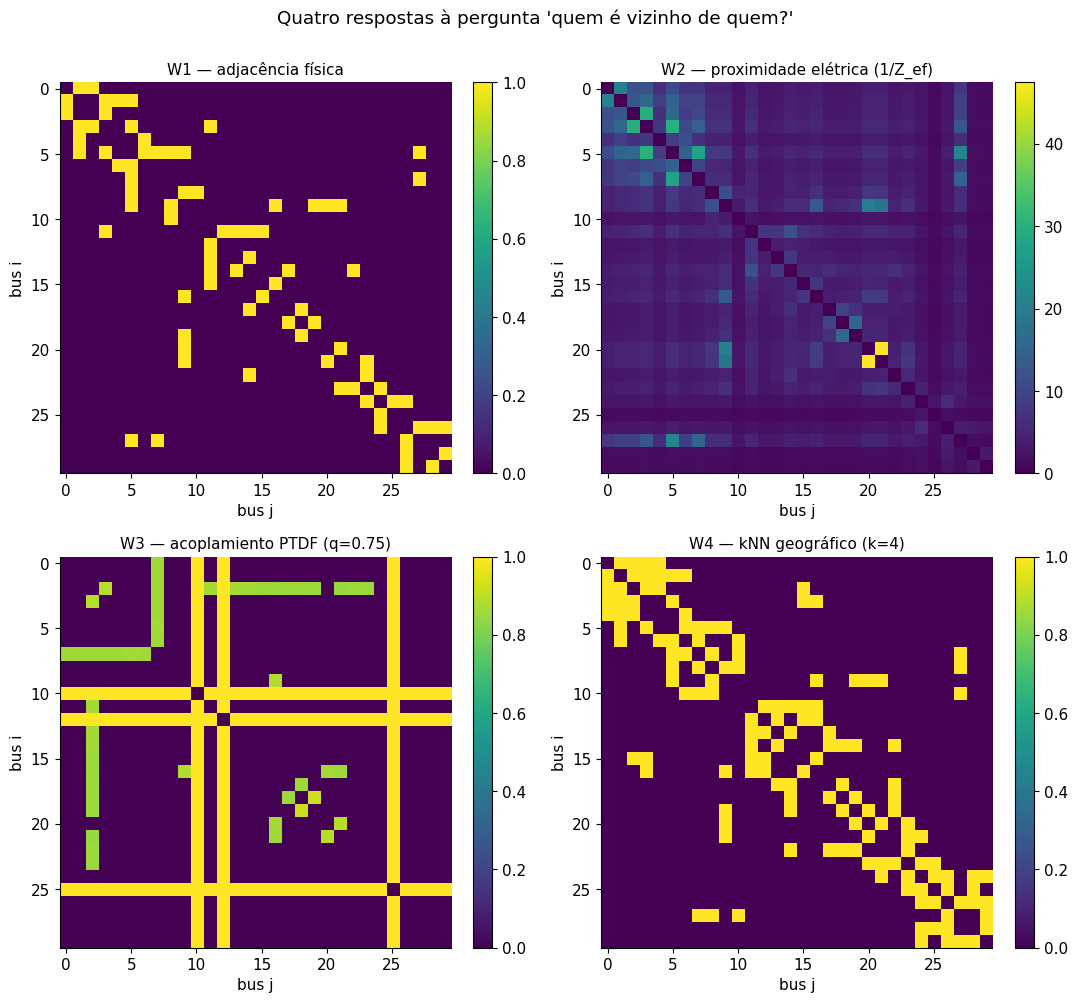

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, (nombre, W) in zip(axes.flat,
        [("W1 — adjacência física", W1), ("W2 — proximidade elétrica (1/Z_ef)", W2),
         ("W3 — acoplamiento PTDF (q=0.75)", W3), ("W4 — kNN geográfico (k=4)", W4)]):
    im = ax.imshow(W, cmap="viridis")
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("bus j"); ax.set_ylabel("bus i"); ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Quatro respostas à pergunta 'quem é vizinho de quem?'", y=1.0)
plt.tight_layout(); plt.show()

💡 **Interpretação.** Vejam quão diferentes são:

- **W1** é esparsíssima (~5% dos pares) e binária: só a topologia física.
- **W2** é **densa**: em uma rede elétrica conexa, *todas* as barras se "sentem" entre
  si — a proximidade elétrica decai, mas nunca é zero. (Resultado contraintuitivo n°3:
  eletricamente, não existem vizinhanças fechadas.)
- **W3** resgata acoplamentos de fluxo que a adjacência não vê: pares de barras distantes
  que compartilham um gargalo.
- **W4** ignora por completo a eletricidade: duas barras vizinhas no mapa podem estar
  conectadas por... nada.

### 7.1 Padronização por linhas e comparação de vizinhanças

Antes de usar $W$ em um modelo SAR costuma-se **padronizar por linhas** ($\tilde W$ com linhas
que somam 1): assim $\tilde W y$ é a *média dos vizinhos*. E para quantificar quão
diferentes são nossas quatro escolhas, correlacionamos suas entradas.

Chequeo: tras estandarizar, as linhas de W1 somam [1. 1. 1. 1. 1.] ...


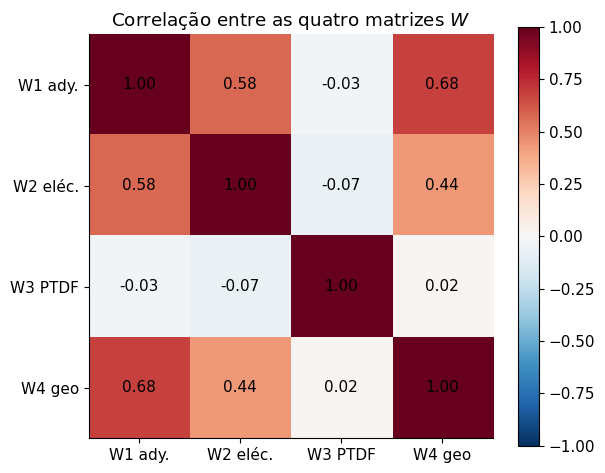

In [25]:
def padronizar_linhas(W):
    "Divide cada linha por seu soma (linhas vacías ficam em zero)."
    s = W.sum(axis=1)
    s_seguro = np.where(s == 0, 1.0, s)
    return W / s_seguro[:, None]

Ws = {"W1 ady.": W1, "W2 eléc.": W2, "W3 PTDF": W3, "W4 geo": W4}
W1t = padronizar_linhas(W1)
print("Chequeo: tras estandarizar, as linhas de W1 somam", 
      np.round(W1t.sum(axis=1)[:5], 6), "...")

# correlação entre as W vectorizadas (só fora da diagonal)
off = ~np.eye(n, dtype=bool)
nombres = list(Ws)
corr = pd.DataFrame(index=nombres, columns=nombres, dtype=float)
for a in nombres:
    for b in nombres:
        corr.loc[a, b] = np.corrcoef(Ws[a][off], Ws[b][off])[0, 1]

fig, ax = plt.subplots(figsize=(6.2, 5))
im = ax.imshow(corr.values.astype(float), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(4), nombres); ax.set_yticks(range(4), nombres)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center")
ax.set_title("Correlação entre as quatro matrizes $W$"); ax.grid(False)
plt.colorbar(im); plt.tight_layout(); plt.show()

💡 **Interpretação.** As correlações moderadas confirmam a mensagem metodológica da
lição: **a escolha de $W$ não é um detalhe técnico, é uma hipótese substantiva** sobre
o mecanismo de interação. Na Sessão 2, quando estimarmos um SAR sobre dados da rede,
repetiremos a estimação com duas $W$ distintas e veremos como mudam $\rho$ e os efeitos
de spillover.

✏️ **Para refletir:** qual $W$ vocês usariam para modelar (a) contágio de congestionamento entre zonas
de preço, (b) difusão da adoção de painéis solares entre municípios? Por que não a mesma?

---
## 8 · Síntese da sessão

| Conceito | Objeto matemático | O que nos disse do IEEE 30 |
|---|---|---|
| Estrutura | $A$, graus | Rede esparsa, sem hubs: $\langle k\rangle\approx 2.7$ |
| Cohesão | $\lambda_2$, vetor de Fiedler | Duas zonas naturais unidas por poucas linhas de fronteira |
| Física | $P = B\,\theta$ | O fluxo DC é difusão sobre o Laplaciano; validado a $10^{-13}$° |
| Influência | PTDF, betweenness elétrica | A eletricidade não segue caminhos mais curtos: rankings ≠ topologia |
| Fragilidade | Cascata Motter–Lai | Robusta ao acaso, frágil ao ataque; a robustez é de limiar |
| Vizinhança | $W_1,\dots,W_4$ | Quatro definições defensáveis → quatro redes distintas |

### 🏠 Mini-exercícios para antes do laboratório

1. **Espectral:** elimine uma das arestas "fronteira" vermelhas de §3.1 e recalcule
   $\lambda_2$. Subiu ou desceu? Por quê?
2. **DC:** duplique a carga da barra de maior consumo e rode §4.3 de novo.
   Continua coincidindo com pandapower? (Cuidado: é preciso rodar `rundcpp` de novo.)
3. **PTDF:** encontre o par de barras $(i,j)$ com maior entrada em $W_3$. Qual linha é
   a que mais se "sacode" quando elas transacionam entre si? Localizem-na no mapa de §1.2.
4. **Cascadas:** repita §6.3 atacando um nó de **grau 1**. Existe algum $\alpha < 2$
   que produzca cascata? Explique.

### 📚 Referências da sessão

- Pagani, G. A. & Aiello, M. (2013). *The Power Grid as a complex network: A survey.* Physica A.
- Wang, Z., Scaglione, A. & Thomas, R. (2011). *Electrical centrality measures for electric power grid vulnerability analysis.* IEEE.
- Motter, A. E. & Lai, E.-C. (2002). *Cascade-based attacks on complex networks.* Phys. Rev. E.
- Dörfler, F., Simpson-Porco, J. & Bullo, F. (2018). *Electrical networks and algebraic graph theory.* Proc. IEEE.
- Klein, D. J. & Randić, M. (1993). *Resistance distance.* J. Math. Chem.
- Fiedler, M. (1973). *Algebraic connectivity of graphs.* Czech. Math. J.